In [2]:
import numpy as np
import struct
import matplotlib.pyplot as plt
import os
from PIL import Image
from PIL import ImageFilter
import random
from tqdm import tqdm

In [3]:
images_filename = "train-images.idx3-ubyte"
labels_filename = "train-labels.idx1-ubyte"

In [4]:
def load_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [5]:
images = load_images(images_filename)
labels = load_labels(labels_filename)

In [6]:
def show_image(image, label):
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()
def show_random_image(images, labels):
    index = np.random.randint(0, len(images))
    show_image(images[index, :, :], labels[index])

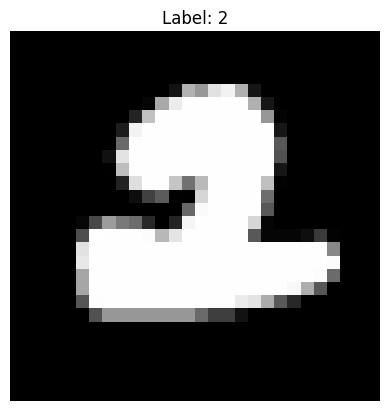

In [7]:
show_random_image(images, labels)

In [8]:
def rescale_images(images, target_size=(16, 16)):
    N = images.shape[0]
    resized = np.zeros((N, target_size[1], target_size[0]), dtype=images.dtype)

    for i in range(N):
        # Convert to PIL image, resize, convert back
        img = Image.fromarray(images[i])
        img = img.resize(target_size, Image.LANCZOS)
        resized[i] = np.array(img)

    return resized

In [9]:
scaled_images = rescale_images(images, target_size=(16, 16))

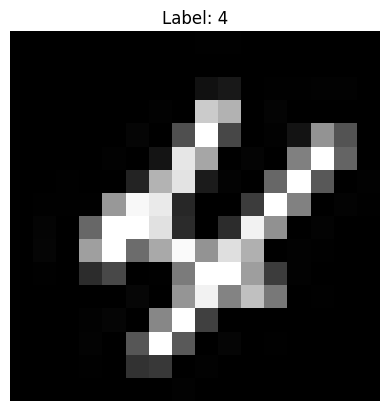

In [10]:
show_random_image(scaled_images, labels)

In [11]:
import random

# ---------- helpers ---------- #
def _find_bbox(arr, thresh=10):
    ys, xs = np.where(arr > thresh)
    if xs.size == 0 or ys.size == 0:          # blank image
        return 0, 0, arr.shape[1], arr.shape[0]
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1

def _pad_to_canvas(pil_img, canvas_size):
    w, h           = pil_img.size
    cw, ch         = canvas_size
    scale          = min(cw / w, ch / h)
    nw, nh         = int(round(w * scale)), int(round(h * scale))
    img_resized    = pil_img.resize((nw, nh), Image.LANCZOS)
    canvas         = Image.new("L", canvas_size, 0)
    canvas.paste(img_resized, ((cw - nw) // 2, (ch - nh) // 2))
    return canvas

def _random_place(pil_img, canvas_size):
    cw, ch         = canvas_size
    w, h           = pil_img.size
    # if it still slipped through, just center it
    if w > cw or h > ch:
        return _pad_to_canvas(pil_img, canvas_size)
    x              = random.randrange(0, cw - w + 1)
    y              = random.randrange(0, ch - h + 1)
    canvas         = Image.new("L", canvas_size, 0)
    canvas.paste(pil_img, (x, y))
    return canvas


def _binarize(pil_img, fallback_thresh=128, min_thr=20, max_thr=235):
    """
    Convert a PIL grayscale image to a 0/255 uint8 array using
    a per‑image Otsu threshold.  If Otsu’s threshold is outside
    [min_thr, max_thr] we fall back to `fallback_thresh`.

    Returns
    -------
    np.ndarray  # shape (H, W), dtype uint8, values {0,255}
    """
    arr   = np.asarray(pil_img, dtype=np.uint8)
    hist  = np.bincount(arr.ravel(), minlength=256)

    # ----- Otsu threshold -----
    total       = arr.size
    sum_total   = np.dot(np.arange(256), hist)

    weight_b    = 0
    sum_b       = 0
    var_max     = -1
    thr_otsu    = fallback_thresh

    for t in range(256):
        weight_b += hist[t]
        if weight_b == 0:            # still background
            continue
        weight_f = total - weight_b
        if weight_f == 0:            # all foreground
            break

        sum_b    += t * hist[t]
        mean_b    = sum_b / weight_b
        mean_f    = (sum_total - sum_b) / weight_f

        # between‑class variance
        var_between = weight_b * weight_f * (mean_b - mean_f) ** 2
        if var_between > var_max:
            var_max   = var_between
            thr_otsu  = t

    # sanity check: blank images or full white occasionally give crazy thresholds
    if not (min_thr <= thr_otsu <= max_thr):
        thr_otsu = fallback_thresh

    return ((arr >= thr_otsu) * 255).astype(np.uint8)

# ---------- main ---------- #
def augment_mnist(
        images,
        labels,
        target_size=(16, 16),
        fallback_thr=128,
        min_thr=20,
        max_thr=235,
        random_scale_range=(0.55, 0.9),
        rng_seed=None,
):
    if rng_seed is not None:
        random.seed(rng_seed)

    cw, ch       = target_size
    out_images   = []
    out_labels   = []

    for arr28, label in tqdm(zip(images, labels), total=len(images), desc="Augmenting"):
        pil_full  = Image.fromarray(arr28)
        left, top, right, bottom = _find_bbox(arr28)
        pil_crop  = pil_full.crop((left, top, right, bottom))

        # 1. straight resize of the 28×28 frame
        v1 = pil_full.resize(target_size, Image.LANCZOS)

        # 2. tight crop scaled to max‑fill 16×16 and centered
        v2 = _pad_to_canvas(pil_crop, target_size)

        # 3–4. random scale + random placement, guaranteed to fit
        v_random = []
        for _ in range(2):
            w0, h0   = pil_crop.size
            # the biggest scale that still fits
            max_scale = min(cw / w0, ch / h0)
            # clamp the requested range so low < high ≤ max_scale
            low       = random_scale_range[0]
            high      = random_scale_range[1]
            high      = min(high, max_scale)
            if low >= high:                 # rare corner case
                low = high * 0.8
            sf        = random.uniform(low, high)
            sw, sh    = max(1, int(round(w0 * sf))), max(1, int(round(h0 * sf)))
            scaled    = pil_crop.resize((sw, sh), Image.LANCZOS)
            v_random.append(_random_place(scaled, target_size))

        for v in (v1, v2, *v_random):
            out_images.append(_binarize(v, fallback_thr, min_thr, max_thr))
            out_labels.append(label)

    return np.stack(out_images, axis=0), np.asarray(out_labels, dtype=labels.dtype)

# usage
# aug_imgs, aug_lbls = augment_mnist(images, labels, rng_seed=42)
# print(aug_imgs.shape)   # (240000, 16, 16)


In [12]:
better_images, better_labels = augment_mnist(images, labels, rng_seed=42)

Augmenting: 100%|██████████| 60000/60000 [00:35<00:00, 1670.70it/s]


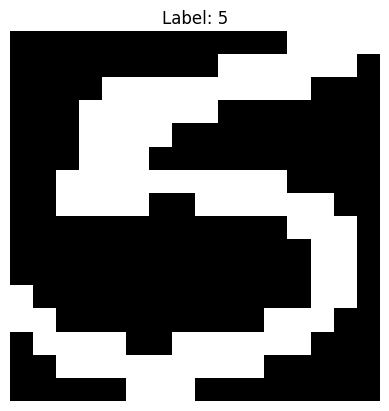

In [114]:
show_random_image(better_images, better_labels)

In [14]:
better_images.shape

(240000, 16, 16)

In [15]:
better_labels.shape

(240000,)

In [16]:
# save the images and labels
np.savez_compressed("mnist_augmented.npz", images=better_images, labels=better_labels)